In [18]:
import pandas as pd

df1 = pd.read_csv("ildenh-arduino.csv")
df2 = pd.read_csv("lilleaila-arduino.csv")
df1.columns

Index(['Timestamp', 'Temperature (C)', 'Humidity (%)', 'Sound', 'Light'], dtype='object')

<Axes: >

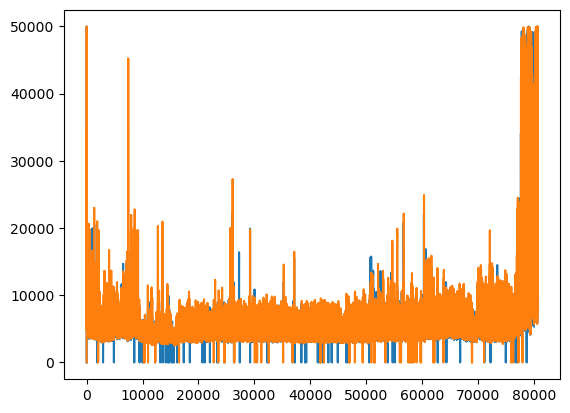

In [5]:
df1["Sound"].plot()
df2["Sound"].plot()

<Axes: >

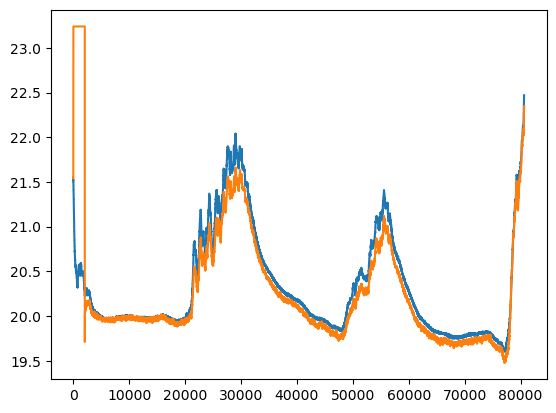

In [6]:
df1["Temperature (C)"].plot()
df2["Temperature (C)"].plot()

<Axes: >

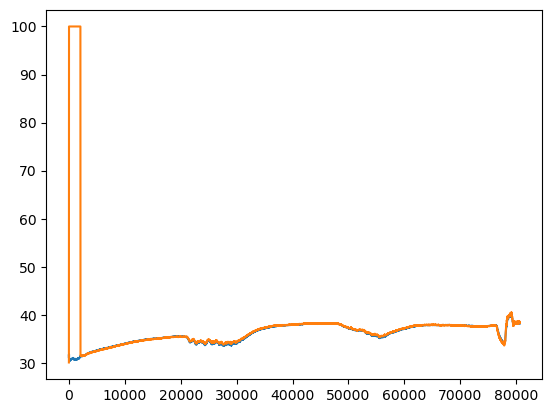

In [7]:
df1["Humidity (%)"].plot()
df2["Humidity (%)"].plot()

<Axes: >

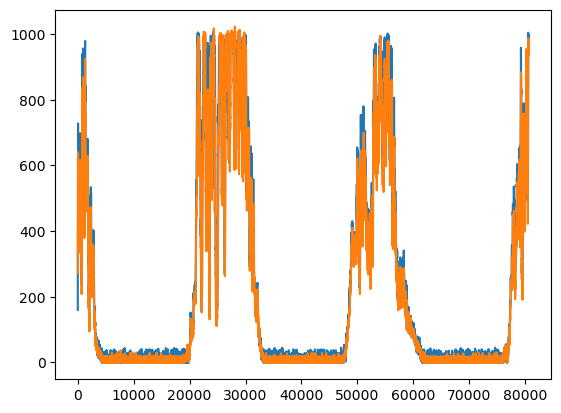

In [8]:
df1["Light"].plot()
df2["Light"].plot()

In [21]:
baseline_diff = df1["Sound"].mean() - df2["Sound"].mean()
print(baseline_diff)

-341.2294684940762


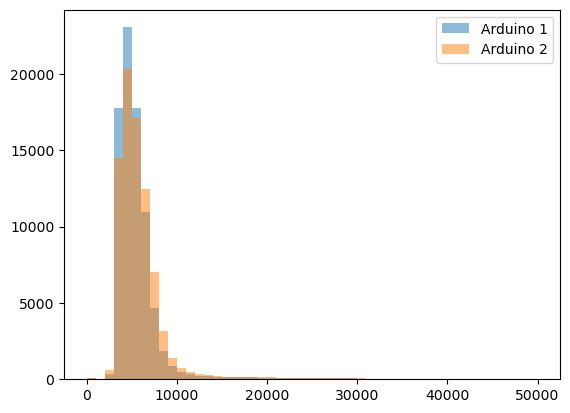

In [22]:
import matplotlib.pyplot as plt

plt.hist(df1["Sound"], bins=50, alpha=0.5, label="Arduino 1")
plt.hist(df2["Sound"], bins=50, alpha=0.5, label="Arduino 2")
plt.legend()
plt.show()

<Axes: >

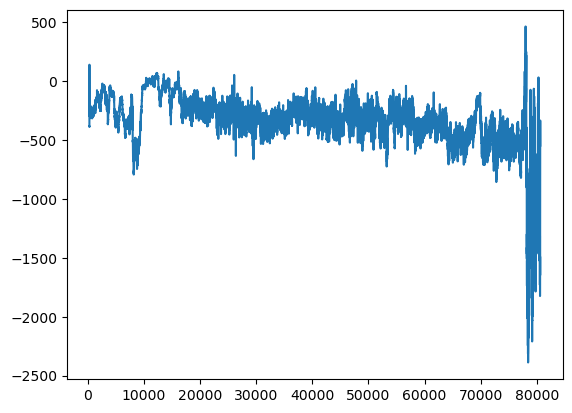

In [27]:
rolling_diff = (df1["Sound"] - df2["Sound"]).rolling(300).mean()
rolling_diff.plot()

In [28]:
from scipy.stats import ttest_ind

ttest_ind(df1["Sound"], df2["Sound"])

TtestResult(statistic=np.float64(-19.178709003216568), pvalue=np.float64(6.881312530723137e-82), df=np.float64(161260.0))

In [29]:
df1_night = df1.loc[20000:50000, "Sound"]
df2_night = df2.loc[20000:50000, "Sound"]

<Axes: >

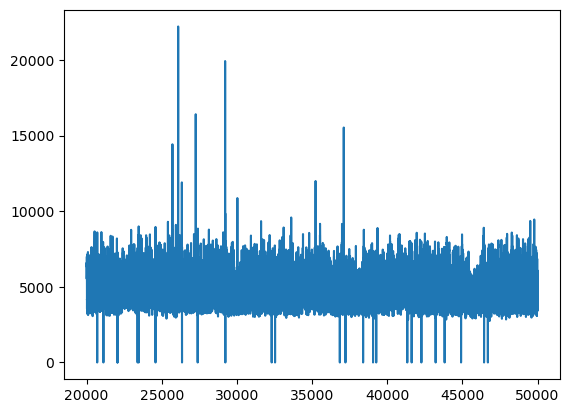

In [31]:
df1_night.plot()

<Axes: >

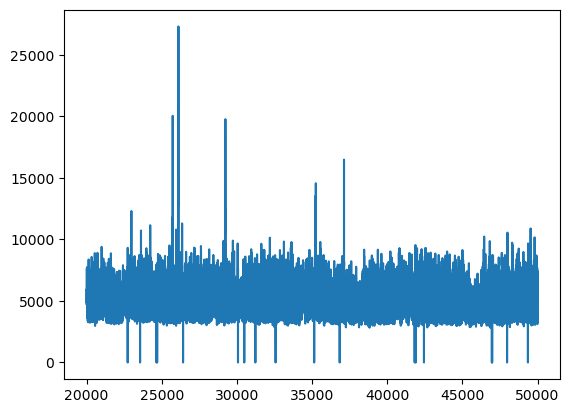

In [32]:
df2_night.plot()

In [36]:
baseline_diff = df1_night.mean() - df2_night.mean()
print(baseline_diff)

-302.9188813706214


In [37]:
baseline_diff = df1_night.median() - df2_night.median()
print(baseline_diff)

-283.78000000000065


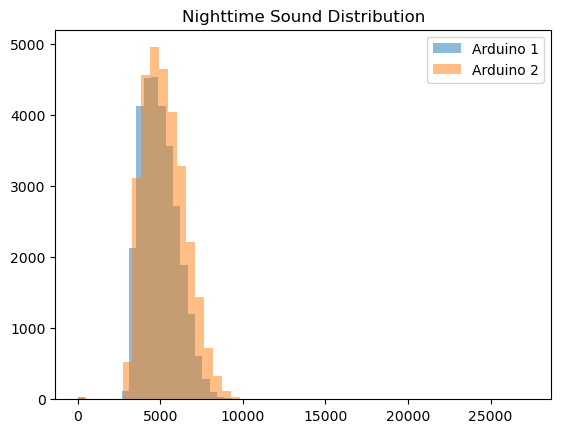

In [38]:
import matplotlib.pyplot as plt

plt.hist(df1_night, bins=50, alpha=0.5, label="Arduino 1")
plt.hist(df2_night, bins=50, alpha=0.5, label="Arduino 2")
plt.legend()
plt.title("Nighttime Sound Distribution")
plt.show()

In [39]:
diff = df1_night - df2_night
print("Mean diff:", diff.mean())
print("Std diff:", diff.std())

Mean diff: -302.91888137062097
Std diff: 1568.3914413603475


<Axes: title={'center': 'Rolling Difference (Night)'}>

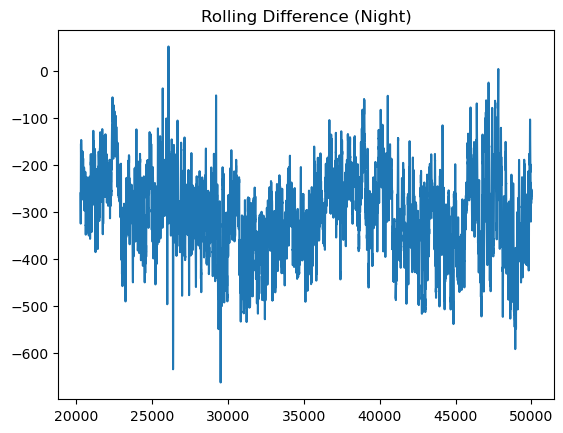

In [48]:
rolling_diff = (df1_night.rolling(300).mean() - df2_night.rolling(300).mean())
rolling_diff.plot(title="Rolling Difference (Night)")

In [41]:
print(len(df1_night), len(df2_night))

30001 30001


In [45]:
offset = (df1_night - df2_night).median()
offset

np.float64(-257.91000000000076)

In [46]:
from scipy.stats import ttest_ind

ttest_ind(df1_night, df2_night)

TtestResult(statistic=np.float64(-30.86504961351959), pvalue=np.float64(1.4959468480377363e-207), df=np.float64(60000.0))

In [49]:
import numpy as np

# Example data
a = df1_night
b = df2_night

differences = a - b
bias = np.mean(differences)
sd_diff = np.std(differences)
rmse = np.sqrt(np.mean(differences**2))

print(f"Bias: {bias:.3f}")
print(f"95% Limits of Agreement: {bias - 1.96*sd_diff:.3f} to {bias + 1.96*sd_diff:.3f}")
print(f"RMSE: {rmse:.3f}")

Bias: -302.919
95% Limits of Agreement: -3376.915 to 2771.077
RMSE: 1597.351


In [62]:
df2_calib = df2["Sound"] - 200

<Axes: >

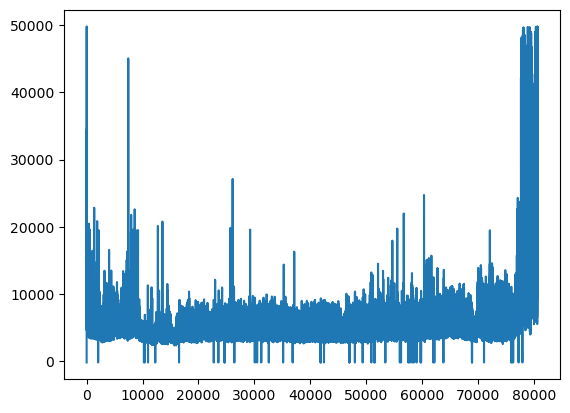

In [63]:
df2_calib.plot()

<Axes: >

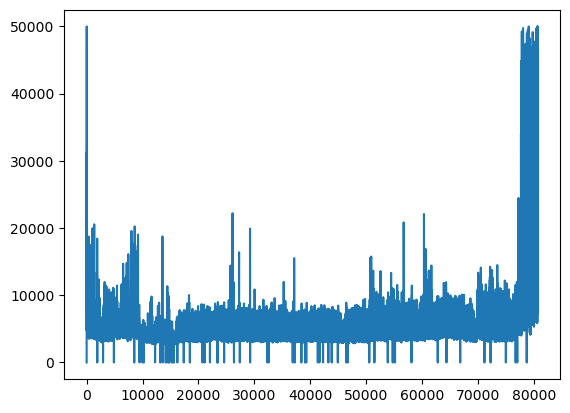

In [64]:
df1["Sound"].plot()

In [65]:
offset = (df1["Sound"] - df2_calib).median()
offset

np.float64(-0.9299999999998363)

In [107]:
df1_roll = df1.rolling(500).mean()
df2_roll = df2.rolling(500).mean()

In [108]:
len(df1_roll)

80626

In [109]:
len(df2_roll)

80636

In [110]:
df3 = pd.DataFrame(
    (df1_roll.to_numpy() + df2_roll.iloc[:80626].to_numpy()) / 2,
    index=df1_roll.index,
    columns=df1_roll.columns
)
df3 = df3.dropna()
df3 = df3[100:]
df3

,Timestamp,Temperature (C),Humidity (%),Sound,Light
599,1052342.5,21.96433,65.34289,5823.48301,482.804
600,1055342.5,21.96356,65.34337,5825.72284,482.553
601,1058342.5,21.96280,65.34385,5827.10185,482.302
602,1061342.5,21.96205,65.34434,5830.22506,482.051
603,1064342.5,21.96129,65.34482,5832.90046,481.798
...,...,...,...,...,...
80621,241299788.0,22.02656,38.38930,21402.54629,721.522
80622,241302788.0,22.02785,38.38911,21475.99638,722.175
80623,241305788.0,22.02914,38.38895,21553.28908,722.825
80624,241308788.0,22.03043,38.38877,21602.28477,723.469


<Axes: >

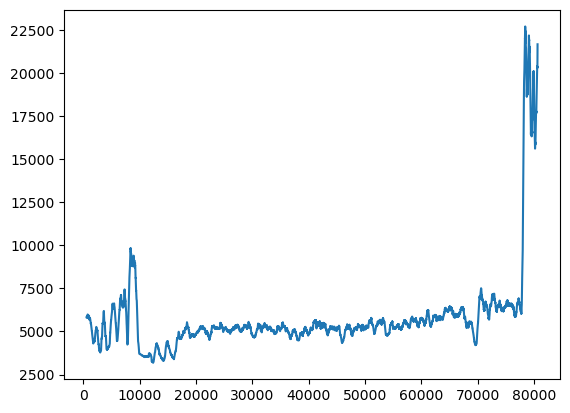

In [111]:
df3["Sound"].plot()

In [117]:
df3_roll = df3.rolling(1000).mean()
df3_roll = df3_roll.dropna()
df3_roll

,Timestamp,Temperature (C),Humidity (%),Sound,Light
1598,2550842.5,21.868605,65.401825,5638.821956,582.082901
1599,2553842.5,21.868517,65.401863,5637.761705,582.224736
1600,2556842.5,21.868430,65.401901,5636.696477,582.366832
1601,2559842.5,21.868344,65.401939,5635.628658,582.509217
1602,2562842.5,21.868259,65.401977,5634.556314,582.651910
...,...,...,...,...,...
80621,239801288.0,21.608139,38.349531,18080.327874,566.390601
80622,239804288.0,21.608794,38.349082,18084.915718,566.636277
80623,239807288.0,21.609450,38.348636,18089.550060,566.882509
80624,239810288.0,21.610107,38.348194,18094.207919,567.129310


<Axes: >

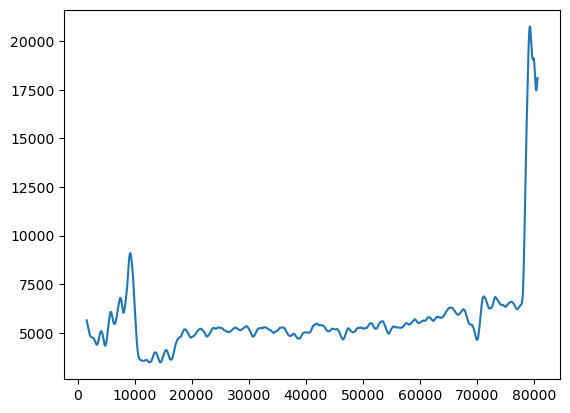

In [118]:
df3_roll["Sound"].plot()